In [1]:
import numpy
import pandas
import matplotlib
import seaborn
import sklearn
import xgboost

print("All packages imported successfully!")


All packages imported successfully!


In [1]:
import rasterio
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# -----------------------------
# CONFIG
# -----------------------------
tif_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\singapore_2011_lcz.tif"

# 2011 dates for 365 days
start_date = datetime(2011, 1, 1)
dates = [start_date + timedelta(days=i) for i in range(365)]

# -----------------------------
# READ TIFF
# -----------------------------
with rasterio.open(tif_file) as src:
    # Rainfall bands: 1–365
    rain_data = src.read(list(range(1, 366)))  # shape = (365, height, width)
    # LCZ band: 366
    lcz_data = src.read(366)  # shape = (height, width)
    transform = src.transform

height, width = lcz_data.shape

# -----------------------------
# CREATE FLATTENED TABLE
# -----------------------------
records = []
for day_idx, date in enumerate(dates):
    for row in range(height):
        for col in range(width):
            x, y = rasterio.transform.xy(transform, row, col)
            rainfall = rain_data[day_idx, row, col]
            lcz = lcz_data[row, col]
            records.append([date.date(), x, y, rainfall, lcz])

df = pd.DataFrame(records, columns=["date", "x", "y", "rainfall", "LCZ"])

# Compute extreme rainfall threshold
threshold = df["rainfall"].quantile(0.95)
df["extreme_rain"] = (df["rainfall"] >= threshold).astype(int)

# -----------------------------
# QUICK CHECK
# -----------------------------
print(df.head())
print("\nRainfall summary:")
print(df["rainfall"].describe())
print("\nLCZ counts:")
print(df["LCZ"].value_counts())

# Optional: save for ML testing
df.to_csv(r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\singapore_2011_flattened.csv", index=False)
print("\nFlattened 2011 dataset saved.")

         date           x         y  rainfall   LCZ  extreme_rain
0  2011-01-01  103.526192  1.606341  6.561907   4.0             0
1  2011-01-01  103.576192  1.606341  5.152329  11.0             0
2  2011-01-01  103.626192  1.606341  6.812189  14.0             0
3  2011-01-01  103.676192  1.606341  5.871259   8.0             0
4  2011-01-01  103.726192  1.606341  6.260865  14.0             0

Rainfall summary:
count    43800.000000
mean         8.230202
std         11.485810
min          0.000000
25%          1.753734
50%          5.348099
75%         10.553170
max        169.789017
Name: rainfall, dtype: float64

LCZ counts:
LCZ
17.0    18250
12.0     7300
4.0      5475
11.0     2920
14.0     2555
8.0      2190
3.0      2190
9.0      1460
10.0      730
6.0       365
13.0      365
Name: count, dtype: int64

Flattened 2011 dataset saved.


In [6]:
import pandas as pd

# Load the flattened CSV
df = pd.read_csv(r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\singapore_2011_flattened.csv")

# Quick check
print(df.head())
print(df.dtypes)

         date           x         y  rainfall   LCZ  extreme_rain
0  2011-01-01  103.526192  1.606341  6.561907   4.0             0
1  2011-01-01  103.576192  1.606341  5.152329  11.0             0
2  2011-01-01  103.626192  1.606341  6.812189  14.0             0
3  2011-01-01  103.676192  1.606341  5.871259   8.0             0
4  2011-01-01  103.726192  1.606341  6.260865  14.0             0
date                str
x               float64
y               float64
rainfall        float64
LCZ             float64
extreme_rain      int64
dtype: object


In [7]:
# Features
X = df[['x', 'y', 'LCZ']]

# Target for regression
y_reg = df['rainfall']

# Target for classification (extreme rainfall)
y_clf = df['extreme_rain']

In [8]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Metrics
def print_metrics(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))
    print()

print_metrics(y_test, y_pred_lr, "Linear Regression")
print_metrics(y_test, y_pred_rf, "Random Forest")

--- Linear Regression ---
MAE: 6.679846474941094
RMSE: 11.461435262468788
R2: -0.00014149542082297906

--- Random Forest ---
MAE: 6.701285150891193
RMSE: 11.493934451629604
R2: -0.005821389702344915



In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_clf = rf_clf.predict(X_test)

print(classification_report(y_test, y_pred_clf))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      8324
           1       0.00      0.00      0.00       436

    accuracy                           0.95      8760
   macro avg       0.48      0.50      0.49      8760
weighted avg       0.90      0.95      0.93      8760



C:\Users\janaa\anaconda3\envs\urban_rainfall\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\janaa\anaconda3\envs\urban_rainfall\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\janaa\anaconda3\envs\urban_rainfall\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

# Preliminary Machine Learning Tests on Flattened Dataset

1. Regression: Predicting Rainfall as Continuous
   
Model	           MAE (mm)	RMSE (mm)   R²
Linear Regression	6.68	11.46	-0.0001
Random Forest	    6.70	11.49	-0.0058

## Interpretation:

R² ≈ 0 → The models are not capturing meaningful patterns; predictions are basically the mean of the rainfall.

MAE ≈ 6–7 mm → Average daily error is around 6–7 mm, which is expected given that extreme rainfall is rare and daily rainfall is inherently chaotic.

* Only spatial features (x, y, LCZ) are used. Rainfall depends on many other factors (e.g., weather, local dynamics) that are not included.


2. Classification: Predicting Extreme Rainfall Events
   
Metric	Class 0 (no extreme)	Class 1 (extreme)
Precision	         0.95	            0.00
Recall	             1.00	            0.00
F1-score	         0.97	            0.00
Support	            8324	            436

## Interpretation:

Class imbalance: Extreme rainfall events are rare → only 436 of 8760 days.

Classifier behavior: Random Forest predicts almost all days as 0 (no extreme).

Result: Accuracy is high (95%) because the majority class dominates, but the model completely fails for extreme events.

Conclusion: The poor metrics for extreme events are expected, not a coding issue.

3. Options for Handling Imbalance / Improving Models
   
Approach	What it does	Pros	Cons	Recommended?

**Oversampling** Duplicate extreme events so the model sees them more often	Makes model learn extremes Risk of overfitting (memorizing rare events)	Optional, careful use

**Undersampling**	Remove majority class examples to balance dataset	Makes classes equal	Lose most normal-day information	Not ideal for your dataset

* **Class weighting**	Tell the model to “care more” about rare events	Keeps all original data, naturally balances learning	No new info, model still may struggle if features are weak	Recommended

Note: None of these steps “fix” the chaotic nature of rainfall. They only help the ML model pay attention to rare events.

4. Optional Features for Future Experiments

* Weather variables: temperature, humidity, wind, pressure — only if easy download

* Urban features beyond LCZ: building density, land use — can add richer urban context. only if easy download

* Temporal patterns (lags/rolling averages): since i have all days, adding lag features is straightforward. Helps the model learn short-term patterns.

5. Key Takeaways

Current dataset is ML-ready → models fit and predict without errors.

Low R² and poor extreme-event metrics are expected → due to features and natural variability, not coding issues.

ML modeling in the thesis is for structured exploration → insights into urban influence, not for production-level prediction.

In [2]:
import rioxarray as rxr
import xarray as xr
import numpy as np
import os

# -----------------------------
# CONFIG
# -----------------------------
rainfall_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\chrp-Singapore_combined.tif"
lcz_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\SINGAPORE_LCZ.tif"
output_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\chrp-Singapore_combined_with_LCZ.tif"

# -----------------------------
# 1. LOAD RAINFALL STACK
# -----------------------------
rainfall_stack = rxr.open_rasterio(rainfall_file, masked=True)
print("Rainfall stack shape (bands, y, x):", rainfall_stack.shape)

# -----------------------------
# 2. LOAD LCZ AND TAKE FIRST BAND
# -----------------------------
lcz = rxr.open_rasterio(lcz_file, masked=True)
lcz_single = lcz.isel(band=0)
print("Original LCZ shape (band 0):", lcz_single.shape)

# -----------------------------
# 3. RESAMPLE LCZ TO MATCH RAINFALL GRID
# -----------------------------
lcz_resampled = lcz_single.rio.reproject_match(rainfall_stack)
print("Resampled LCZ shape:", lcz_resampled.shape)

# Round LCZ to nearest integer class
lcz_resampled = xr.DataArray(np.rint(lcz_resampled.data), coords=lcz_resampled.coords)
print("LCZ rounded to integer classes.")

# -----------------------------
# 4. COMBINE RAINFALL + LCZ
# -----------------------------
combined = xr.concat([rainfall_stack, lcz_resampled], dim="band")
print("Combined raster shape (bands, y, x):", combined.shape)

# -----------------------------
# 5. SAVE COMBINED TIFF
# -----------------------------
combined.rio.to_raster(output_file)
print(f"\nCombined rainfall + LCZ raster saved to: {output_file}")

Rainfall stack shape (bands, y, x): (5842, 19, 24)
Original LCZ shape (band 0): (546, 684)
Resampled LCZ shape: (19, 24)
LCZ rounded to integer classes.
Combined raster shape (bands, y, x): (5843, 19, 24)

Combined rainfall + LCZ raster saved to: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\chrp-Singapore_combined_with_LCZ.tif


In [6]:
import pandas as pd
import numpy as np
import rasterio

# Load your CSV
csv_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_ML_ready.csv"
df = pd.read_csv(csv_path)

# Load raster to get transform
raster_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\chrp-Singapore_combined_with_LCZ.tif"
with rasterio.open(raster_path) as src:
    transform = src.transform
    width = src.width

# Compute x and y from pixel_id
pixel_ids = df['pixel_id'].values
df['x'] = transform[2] + (pixel_ids % width) * transform[0]
df['y'] = transform[5] + (pixel_ids // width) * transform[4]

# Save updated CSV
df.to_csv(r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_ML_ready_with_coords.csv", index=False)

In [29]:
import xarray as xr
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
nc_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_2011_2025_processed.nc"
weather_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Raw\london_weather_combined.csv"
output_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_final.csv"

# -----------------------------
# Load NetCDF (rain data)
# -----------------------------
ds = xr.open_dataset(nc_path)
rain_df = ds.to_dataframe().reset_index()

# Rename time column
rain_df = rain_df.rename(columns={"valid_time": "date"})

# -----------------------------
# Create "number" column
# Define extreme rainfall threshold (adjust if needed)
# -----------------------------
threshold = 1.0  # example threshold in mm (you can tune this)

rain_df["number"] = (rain_df["tp"] >= threshold).astype(int)

# -----------------------------
# Add LCZ (constant for London)
# -----------------------------
rain_df["avg_LCZ_city"] = 8.68

# -----------------------------
# Load weather data
# -----------------------------
weather_df = pd.read_csv(weather_path)

# Ensure date column exists and is named correctly
weather_df["date"] = pd.to_datetime(weather_df["date"]).dt.date
rain_df["date"] = pd.to_datetime(rain_df["date"]).dt.date

# -----------------------------
# Merge weather into rain data
# -----------------------------
final_df = rain_df.merge(weather_df, on="date", how="left")

# -----------------------------
# Select and reorder columns
# -----------------------------
final_df = final_df[[
    "date",
    "latitude",
    "longitude",
    "tp",
    "number",
    "avg_LCZ_city",
    "tavg",
    "tmin",
    "tmax",
    "pres",
    "wspd"
]]

# -----------------------------
# Save
# -----------------------------
final_df.to_csv(output_path, index=False)

print("London dataset rebuilt successfully.")
print(final_df.head(10))

London dataset rebuilt successfully.
         date  latitude  longitude        tp  number  avg_LCZ_city  tavg  \
0  2011-01-01      51.5      -0.50  1.093388       1          8.68   5.6   
1  2011-01-01      51.5      -0.25  1.057148       1          8.68   5.6   
2  2011-01-01      51.5       0.00  1.054287       1          8.68   5.6   
3  2011-01-01      51.5       0.25  0.846386       0          8.68   5.6   
4  2011-01-02      51.5      -0.50  0.009060       0          8.68   2.9   
5  2011-01-02      51.5      -0.25  0.006676       0          8.68   2.9   
6  2011-01-02      51.5       0.00  0.004292       0          8.68   2.9   
7  2011-01-02      51.5       0.25  0.003338       0          8.68   2.9   
8  2011-01-03      51.5      -0.50  0.100613       0          8.68   1.4   
9  2011-01-03      51.5      -0.25  0.073910       0          8.68   1.4   

   tmin  tmax    pres  wspd  
0   4.1   7.2  1025.0  10.1  
1   4.1   7.2  1025.0  10.1  
2   4.1   7.2  1025.0  10.1  
3   4.

In [36]:
import pandas as pd
import os

processed_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed"

cities = {
    "London": {
        "main": "London_final.csv",
        "buildings": "London_buildings.csv"
    },
    "New_York": {
        "main": "New_York_tp_lcz_w.csv",
        "buildings": "New_York_City_buildings.csv"
    },
    "Singapore": {
        "main": "Singapore_tp_lcz_w.csv",
        "buildings": "Singapore_buildings.csv"
    },
    "Tokyo": {
        "main": "Tokyo_tp_lcz_w.csv",
        "buildings": "Tokyo_buildings.csv"
    }
}

for city, files in cities.items():
    main_path = os.path.join(processed_path, files["main"])
    bld_path = os.path.join(processed_path, files["buildings"])
    
    # Load original files (no modification)
    main_df = pd.read_csv(main_path)
    bld_df = pd.read_csv(bld_path)
    
    # Add city column if not present
    if "city" not in main_df.columns:
        main_df["city"] = city
    
    # Merge building features (broadcast across all rows)
    merged_df = main_df.merge(bld_df, on="city", how="left")
    
    # Save as NEW file (do not overwrite originals)
    output_file = f"{city}_Rlczbdw.csv"
    output_path = os.path.join(processed_path, output_file)
    
    merged_df.to_csv(output_path, index=False)
    
    print(f"\n{city} merged successfully")
    print(f"Saved → {output_file}")
    print(f"Shape: {merged_df.shape}")


London merged successfully
Saved → London_Rlczbdw.csv
Shape: (21916, 17)

New_York merged successfully
Saved → New_York_Rlczbdw.csv
Shape: (32874, 17)

Singapore merged successfully
Saved → Singapore_Rlczbdw.csv
Shape: (10958, 17)

Tokyo merged successfully
Saved → Tokyo_Rlczbdw.csv
Shape: (10958, 17)


In [41]:
import pandas as pd
import os

processed_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed"

cities = {
    "London": {
        "main": "London_final.csv",
        "buildings": "London_buildings.csv"
    },
    "New_York": {
        "main": "New_York_tp_lcz_w.csv",
        "buildings": "New_York_City_buildings.csv"
    },
    "Singapore": {
        "main": "Singapore_tp_lcz_w.csv",
        "buildings": "Singapore_buildings.csv"
    },
    "Tokyo": {
        "main": "Tokyo_tp_lcz_w.csv",
        "buildings": "Tokyo_buildings.csv"
    }
}

# Check each city's merged data
for city, files in cities.items():
    main_path = os.path.join(processed_path, files["main"])
    bld_path = os.path.join(processed_path, files["buildings"])
    
    # Load original files (no modification)
    main_df = pd.read_csv(main_path)
    bld_df = pd.read_csv(bld_path)
    
    # Add city column if not present
    if "city" not in main_df.columns:
        main_df["city"] = city
    
    # Merge building features (broadcast across all rows)
    merged_df = main_df.merge(bld_df, on="city", how="left")
    
    # Save as NEW file (do not overwrite originals)
    output_file = f"{city}_Rlczbdw.csv"
    output_path = os.path.join(processed_path, output_file)
    
    merged_df.to_csv(output_path, index=False)
    
    # Display results
    print(f"\n{city} merged successfully")
    print(f"Saved → {output_file}")
    print(f"Shape: {merged_df.shape}")
    
    print(f"Columns:\n{merged_df.columns.tolist()}")
    print(f"\nPreview:\n{merged_df.head()}")
    print(f"\nMissing values:\n{merged_df.isnull().sum()}")


London merged successfully
Saved → London_Rlczbdw.csv
Shape: (21916, 17)
Columns:
['date', 'latitude', 'longitude', 'tp', 'number', 'avg_LCZ_city', 'tavg', 'tmin', 'tmax', 'pres', 'wspd', 'city', 'city_area_km2', 'building_count', 'buildings_per_km2', 'total_building_area_km2', 'building_area_density']

Preview:
         date  latitude  longitude        tp  number  avg_LCZ_city  tavg  \
0  2011-01-01      51.5      -0.50  1.093388       1          8.68   5.6   
1  2011-01-01      51.5      -0.25  1.057148       1          8.68   5.6   
2  2011-01-01      51.5       0.00  1.054287       1          8.68   5.6   
3  2011-01-01      51.5       0.25  0.846386       0          8.68   5.6   
4  2011-01-02      51.5      -0.50  0.009060       0          8.68   2.9   

   tmin  tmax    pres  wspd    city  city_area_km2  building_count  \
0   4.1   7.2  1025.0  10.1  London    4179.467175          660051   
1   4.1   7.2  1025.0  10.1  London    4179.467175          660051   
2   4.1   7.2  102

In [42]:
import pandas as pd
import os

# Path for processed data
processed_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed"

# Paths to main and building files
main_file_path = os.path.join(processed_path, "New_York_tp_lcz_w.csv")
bld_file_path = os.path.join(processed_path, "New_York_City_buildings.csv")

# Read main data
main_df = pd.read_csv(main_file_path)

# Read building data
bld_df = pd.read_csv(bld_file_path)

# Add the building data to the main dataframe
merged_df = main_df.copy()

# Assuming you want to add the same building info to all rows (based on city)
merged_df['city_area_km2'] = bld_df['city_area_km2'][0]
merged_df['building_count'] = bld_df['building_count'][0]
merged_df['buildings_per_km2'] = bld_df['buildings_per_km2'][0]
merged_df['total_building_area_km2'] = bld_df['total_building_area_km2'][0]
merged_df['building_area_density'] = bld_df['building_area_density'][0]

# Save the merged dataset to the processed folder as New_York_Rlczbdw.csv
output_file_path = os.path.join(processed_path, "New_York_Rlczbdw.csv")
merged_df.to_csv(output_file_path, index=False)

# Check the resulting table
print("Merged data preview:")
print(merged_df.head())

# Check for any missing values
print("\nMissing values:")
print(merged_df.isnull().sum())

Merged data preview:
         date  latitude  longitude        tp  number  avg_LCZ_city  tavg  \
0  2011-01-01     40.75     -74.25  0.000000       0          5.31   3.6   
1  2011-01-01     40.75     -74.00  0.000000       0          5.31   3.6   
2  2011-01-01     40.75     -73.75  0.000000       0          5.31   3.6   
3  2011-01-01     40.50     -74.25  0.000000       0          5.31   3.6   
4  2011-01-01     40.50     -74.00  0.000477       0          5.31   3.6   

   tmin  tmax    pres  wspd  city_area_km2  building_count  buildings_per_km2  \
0   0.6   6.1  1019.3  11.2    3936.297076         1164585         295.858005   
1   0.6   6.1  1019.3  11.2    3936.297076         1164585         295.858005   
2   0.6   6.1  1019.3  11.2    3936.297076         1164585         295.858005   
3   0.6   6.1  1019.3  11.2    3936.297076         1164585         295.858005   
4   0.6   6.1  1019.3  11.2    3936.297076         1164585         295.858005   

   total_building_area_km2  buildin

In [46]:
import pandas as pd

# List of the merged files to check
files = [
    "London_Rlczbdw.csv",
    "New_York_Rlczbdw.csv",
    "Singapore_Rlczbdw.csv",
    "Tokyo_Rlczbdw.csv"
]

# Preview each file
for file in files:
    file_path = os.path.join(processed_path, file)
    df = pd.read_csv(file_path)
    
    print(f"================= {file} =================")
    print("Columns:", df.columns.tolist())
    print("Data types:", df.dtypes)
    print("Full table:\n", df)
    print("\nPreview:\n", df.head())  # Preview first few rows
    print("==============================================\n")

================= London_Rlczbdw.csv =================
Columns: ['date', 'latitude', 'longitude', 'tp', 'number', 'avg_LCZ_city', 'tavg', 'tmin', 'tmax', 'pres', 'wspd', 'city_area_km2', 'building_count', 'buildings_per_km2', 'total_building_area_km2', 'building_area_density']
Data types: date                           str
latitude                   float64
longitude                  float64
tp                         float64
number                       int64
avg_LCZ_city               float64
tavg                       float64
tmin                       float64
tmax                       float64
pres                       float64
wspd                       float64
city_area_km2              float64
building_count               int64
buildings_per_km2          float64
total_building_area_km2    float64
building_area_density      float64
dtype: object
Full table:
              date  latitude  longitude        tp  number  avg_LCZ_city  tavg  \
0      2011-01-01      51.5      -0.50  1.0

In [6]:
import xarray as xr
import rasterio
import geopandas as gpd
import pandas as pd

# =====================
# FILE PATHS
# =====================
nc_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_Combined_og_to_mm.nc"
lcz_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_LCZ.tif"
output_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\T_Test_LCZxR.csv"

# =====================
# LOAD DATA
# =====================
ds = xr.open_dataset(nc_file)
lcz = rasterio.open(lcz_file)

rain = ds["tp"]  # your rainfall variable

# =====================
# CONVERT TO DATAFRAME (KEEP TIME)
# =====================
df = rain.to_dataframe().reset_index()

# columns now: valid_time, latitude, longitude, tp

# =====================
# CREATE GEOMETRY
# =====================
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# =====================
# MATCH CRS (just in case)
# =====================
gdf = gdf.to_crs(lcz.crs)

# =====================
# SAMPLE LCZ
# =====================
coords = [(x, y) for x, y in zip(gdf.geometry.x, gdf.geometry.y)]
lcz_values = list(lcz.sample(coords))

gdf["LCZ"] = [v[0] for v in lcz_values]

# =====================
# DROP INVALID
# =====================
if lcz.nodata is not None:
    gdf = gdf[gdf["LCZ"] != lcz.nodata]

gdf = gdf.dropna(subset=["LCZ"])

# =====================
# SAVE
# =====================
gdf.drop(columns="geometry").to_csv(output_file, index=False)

print("Saved:", output_file)

Saved: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\T_Test_LCZxR.csv


In [6]:
import rasterio
import numpy as np
import pandas as pd

# =====================
# FILE PATHS
# =====================
rain_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\chrp-Tokyo_combined.tif"
lcz_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_LCZ.tif"
output_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_full_dataset.csv"

# =====================
# LOAD RASTERS
# =====================
rain_src = rasterio.open(rain_file)
lcz_src = rasterio.open(lcz_file)

transform = rain_src.transform

results = []

# =====================
# LOOP OVER TIME (BANDS)
# =====================
for band_idx in range(1, rain_src.count + 1):

    rain_data = rain_src.read(band_idx)

    # Flatten raster
    rows, cols = np.where(np.isfinite(rain_data))
    values = rain_data[rows, cols]

    # Remove nodata (-9999 etc.)
    valid_mask = values != rain_src.nodata if rain_src.nodata is not None else np.ones_like(values, dtype=bool)
    valid_mask &= (values != -9999)

    rows = rows[valid_mask]
    cols = cols[valid_mask]
    values = values[valid_mask]

    # Convert pixel coords → spatial coords (vectorized)
    xs, ys = rasterio.transform.xy(transform, rows, cols)

    coords = list(zip(xs, ys))

    # =====================
    # SAMPLE LCZ IN BATCH
    # =====================
    lcz_vals = list(lcz_src.sample(coords))

    # Extract first band values
    lcz_vals = [v[0] for v in lcz_vals]

    # =====================
    # STORE RESULTS
    # =====================
    for i in range(len(values)):
        if lcz_src.nodata is not None and lcz_vals[i] == lcz_src.nodata:
            continue

        results.append({
            "time": band_idx,
            "rainfall": float(values[i]),
            "LCZ": int(lcz_vals[i]),
            "x": xs[i],
            "y": ys[i]
        })

# =====================
# CREATE DATAFRAME
# =====================
df = pd.DataFrame(results)

# =====================
# SAVE
# =====================
df.to_csv(output_file, index=False)

print("Saved dataset:", output_file)
print("Shape:", df.shape)

Saved dataset: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_full_dataset.csv
Shape: (4562235, 5)


In [1]:
import os
import re
from datetime import datetime
from collections import Counter

import rasterio
import numpy as np
import pandas as pd
from rasterio.warp import reproject, Resampling

# =====================
# PATHS
# =====================
folder = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Raw"

lcz_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_LCZ.tif"

combined_rain_output = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\chrp-Tokyo_combined.tif"
output_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_full_dataset.csv"

# =====================
# PATTERN
# =====================
pattern = r"Tokyo[-_](\d{4})[-_.](\d{2})[-_.](\d{2})\.tif$"

# =====================
# STEP 1: FIND FILES (IGNORE ONLY 2011 DOT FORMAT)
# =====================
file_to_date = {}
duplicates = []
skipped_dot_2011 = 0

for root, dirs, files in os.walk(folder):
    for f in files:

        # ignore ONLY 2011 dot-format files
        if re.search(r"Tokyo[-_]?2011\.\d{2}\.\d{2}\.tif$", f):
            skipped_dot_2011 += 1
            continue

        match = re.search(pattern, f)
        if match:
            y, m, d = match.groups()
            dt = datetime(int(y), int(m), int(d))

            full_path = os.path.join(root, f)

            if dt in file_to_date:
                duplicates.append((dt, file_to_date[dt], full_path))
            else:
                file_to_date[dt] = full_path

dates_sorted = sorted(file_to_date.keys())
file_paths = [file_to_date[d] for d in dates_sorted]

print("=== FILE SUMMARY ===")
print("Total valid files used:", len(file_paths))
print("Skipped 2011 dot-format files:", skipped_dot_2011)
print("Duplicate dates found:", len(duplicates))

# =====================
# STEP 2: ALIGN + STACK (FIXED)
# =====================
arrays = []
meta = None

with rasterio.open(file_paths[0]) as ref_src:
    ref_transform = ref_src.transform
    ref_crs = ref_src.crs
    ref_shape = (ref_src.height, ref_src.width)
    meta = ref_src.meta.copy()

for fp in file_paths:
    with rasterio.open(fp) as src:
        src_data = src.read(1)

        dst_data = np.empty(ref_shape, dtype=src_data.dtype)

        reproject(
            source=src_data,
            destination=dst_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.nearest
        )

        arrays.append(dst_data)

combined_array = np.stack(arrays, axis=0)

meta.update({
    "count": combined_array.shape[0],
    "transform": ref_transform,
    "crs": ref_crs,
    "height": ref_shape[0],
    "width": ref_shape[1]
})

with rasterio.open(combined_rain_output, "w", **meta) as dst:
    dst.write(combined_array)

print("Combined raster created.")

# =====================
# STEP 3: LOAD LCZ + RAIN
# =====================
rain_src = rasterio.open(combined_rain_output)
lcz_src = rasterio.open(lcz_file)

transform = rain_src.transform

results = []

# =====================
# STEP 4: MAP BANDS → DATES
# =====================
for band_idx in range(1, rain_src.count + 1):

    if band_idx - 1 >= len(dates_sorted):
        break

    dt = dates_sorted[band_idx - 1]

    rain_data = rain_src.read(band_idx)

    rows, cols = np.where(np.isfinite(rain_data))
    values = rain_data[rows, cols]

    if rain_src.nodata is not None:
        mask = values != rain_src.nodata
    else:
        mask = np.ones_like(values, dtype=bool)

    mask &= (values != -9999)

    rows = rows[mask]
    cols = cols[mask]
    values = values[mask]

    xs, ys = rasterio.transform.xy(transform, rows, cols)
    coords = list(zip(xs, ys))

    lcz_vals = [v[0] for v in lcz_src.sample(coords)]

    for i in range(len(values)):
        if lcz_src.nodata is not None and lcz_vals[i] == lcz_src.nodata:
            continue

        results.append({
            "date": dt,
            "rainfall": float(values[i]),
            "LCZ": int(lcz_vals[i]),
            "x": xs[i],
            "y": ys[i]
        })

# =====================
# STEP 5: SAVE CSV
# =====================
df = pd.DataFrame(results)

df = df.dropna()
df = df[df["rainfall"] != -9999]

df.to_csv(output_file, index=False)

print("Saved dataset:", output_file)
print("Shape:", df.shape)

# =====================
# STEP 6: SAMPLE OUTPUT
# =====================
print("\n=== SAMPLE DATA ===")
print(df.head(20))

# =====================
# STEP 7: DATE CHECK
# =====================
print("\n=== DATE CHECK ===")

unique_dates = sorted(df["date"].unique())

missing_dates = set(dates_sorted) - set(unique_dates)
extra_dates = set(unique_dates) - set(dates_sorted)

print("Expected dates:", len(dates_sorted))
print("Found dates:", len(unique_dates))
print("Missing dates:", len(missing_dates))
print("Extra dates:", len(extra_dates))

if missing_dates:
    print("\nMissing (sample):", list(missing_dates)[:10])

year_counts = Counter([d.year for d in unique_dates])
print("\nYear distribution:")
for year in sorted(year_counts):
    print(year, ":", year_counts[year])

=== FILE SUMMARY ===
Total valid files used: 5477
Skipped 2011 dot-format files: 365
Duplicate dates found: 0
Combined raster created.
Saved dataset: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_full_dataset.csv
Shape: (4405335, 5)

=== SAMPLE DATA ===
         date  rainfall  LCZ           x          y
0  2011-01-01       0.0    6  138.940476  36.245378
1  2011-01-01       0.0    9  138.990476  36.245378
2  2011-01-01       0.0    6  139.040476  36.245378
3  2011-01-01       0.0    8  139.090476  36.245378
4  2011-01-01       0.0    6  139.140476  36.245378
5  2011-01-01       0.0    8  139.190476  36.245378
6  2011-01-01       0.0    9  139.240476  36.245378
7  2011-01-01       0.0   14  139.290476  36.245378
8  2011-01-01       0.0    9  139.340476  36.245378
9  2011-01-01       0.0    6  139.390476  36.245378
10 2011-01-01       0.0    6  139.440476  36.245378
11 2011-01-01       0.0    6  139.490476  36.245378
12 2011-01-01       0.0    6  139.540476  36.245378
13 2

In [ ]:
import os
import re
from datetime import datetime
from collections import Counter

import rasterio
import numpy as np
import pandas as pd
from rasterio.warp import reproject, Resampling

# =====================
# CONFIG
# =====================
base_raw_folder = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Raw"
base_output_folder = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed"

cities = ["London", "Singapore", "New_York"]

# =====================
# LOOP OVER CITIES
# =====================
for CITY in cities:

    print("\n" + "="*60)
    print(f"PROCESSING: {CITY}")
    print("="*60)

    folder = base_raw_folder

    lcz_file = os.path.join(base_output_folder, f"{CITY}_LCZ.tif")
    combined_rain_output = os.path.join(base_output_folder, f"chrp-{CITY}_combined.tif")
    output_file = os.path.join(base_output_folder, f"{CITY}_full_dataset.csv")

    # =====================
    # PATTERN
    # =====================
    if CITY == "New_York":
        pattern = r"New_York[-_](\d{4})[-_.](\d{2})[-_.](\d{2})\.tif$"
        dot_pattern = r"New_York[-_]?2011\.\d{2}\.\d{2}\.tif$"
    else:
        pattern = rf"{CITY}[-_](\d{{4}})[-_.](\d{{2}})[-_.](\d{{2}})\.tif$"
        dot_pattern = rf"{CITY}[-_]?2011\.\d{{2}}\.\d{{2}}\.tif$"

    # =====================
    # STEP 1: FIND FILES
    # =====================
    print("Step 1: Scanning files...")

    file_to_date = {}
    duplicates = []
    skipped_dot = 0

    for root, dirs, files in os.walk(folder):
        for f in files:

            if re.search(dot_pattern, f):
                skipped_dot += 1
                continue

            match = re.search(pattern, f)
            if match:
                y, m, d = match.groups()
                dt = datetime(int(y), int(m), int(d))

                full_path = os.path.join(root, f)

                if dt in file_to_date:
                    duplicates.append((dt, file_to_date[dt], full_path))
                else:
                    file_to_date[dt] = full_path

    dates_sorted = sorted(file_to_date.keys())
    file_paths = [file_to_date[d] for d in dates_sorted]

    print("Files used:", len(file_paths))
    print("Skipped dot-format files:", skipped_dot)
    print("Duplicate dates:", len(duplicates))

    # =====================
    # STEP 2: ALIGN + STACK
    # =====================
    print("Step 2: Aligning rasters...")

    arrays = []

    with rasterio.open(file_paths[0]) as ref_src:
        ref_transform = ref_src.transform
        ref_crs = ref_src.crs
        ref_shape = (ref_src.height, ref_src.width)
        meta = ref_src.meta.copy()

    for i, fp in enumerate(file_paths):
        if i % 100 == 0:
            print(f"Processing raster {i+1}/{len(file_paths)}")

        with rasterio.open(fp) as src:
            src_data = src.read(1)

            dst_data = np.empty(ref_shape, dtype=src_data.dtype)

            reproject(
                source=src_data,
                destination=dst_data,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                resampling=Resampling.nearest
            )

            arrays.append(dst_data)

    combined_array = np.stack(arrays, axis=0)

    meta.update({
        "count": combined_array.shape[0],
        "transform": ref_transform,
        "crs": ref_crs,
        "width": ref_shape[1],
        "height": ref_shape[0]
    })

    with rasterio.open(combined_rain_output, "w", **meta) as dst:
        dst.write(combined_array)

    print("Combined raster saved.")

    # =====================
    # STEP 3: BUILD DATASET (FILTERED + LCZ SAMPLING)
    # =====================
    print("Step 3: Building dataset (filtered sampling)...")

    rain_src = rasterio.open(combined_rain_output)
    lcz_src = rasterio.open(lcz_file)

    transform = rain_src.transform

    results = []

    for band_idx in range(1, rain_src.count + 1):

        if band_idx - 1 >= len(dates_sorted):
            break

        dt = dates_sorted[band_idx - 1]

        rain_data = rain_src.read(band_idx)

        # ---- STEP 1: valid pixels only ----
        rows, cols = np.where(np.isfinite(rain_data))
        values = rain_data[rows, cols]

        if rain_src.nodata is not None:
            mask = values != rain_src.nodata
        else:
            mask = np.ones_like(values, dtype=bool)

        mask &= (values != -9999)

        rows = rows[mask]
        cols = cols[mask]
        values = values[mask]

        # ---- STEP 2: convert to coordinates ----
        xs, ys = rasterio.transform.xy(transform, rows, cols)
        coords = list(zip(xs, ys))

        # ---- STEP 3: LCZ sampling ----
        lcz_vals = [v[0] for v in lcz_src.sample(coords)]

        # ---- STEP 4: store records ----
        for i in range(len(values)):

            if lcz_src.nodata is not None and lcz_vals[i] == lcz_src.nodata:
                continue

            results.append({
                "date": dt,
                "rainfall": float(values[i]),
                "LCZ": int(lcz_vals[i]),
                "x": xs[i],
                "y": ys[i]
            })

    df = pd.DataFrame(results)

    # clean final dataset
    df = df.dropna()
    df = df[df["rainfall"] != -9999]

    df.to_csv(output_file, index=False)

    print("Saved CSV:", output_file)
    print("Shape:", df.shape)

    # =====================
    # SUMMARY
    # =====================
    print("\n=== SUMMARY ===")
    print("Date range:", df["date"].min(), "→", df["date"].max())
    print("Unique dates:", df["date"].nunique())
    print("Non-zero rainfall %:", (df["rainfall"] > 0).mean() * 100)

    unique_dates = sorted(df["date"].unique())
    year_counts = Counter([d.year for d in unique_dates])

    print("\nYear distribution:")
    for year in sorted(year_counts):
        print(year, ":", year_counts[year])


PROCESSING: London
Step 1: Scanning files...
Files used: 5477
Skipped dot-format files: 365
Duplicate dates: 0
Step 2: Aligning rasters...
Processing raster 1/5477
Processing raster 101/5477
Processing raster 201/5477


In [3]:
import pandas as pd

files = {
    "Tokyo": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_full_dataset.csv",
    "London": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_full_dataset.csv",
    "Singapore": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_full_dataset.csv",
    "NewYork": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_full_dataset.csv"
}

for city, path in files.items():
    print("\n" + "="*60)
    print(f"CITY: {city}")
    print("="*60)

    df = pd.read_csv(path)

    print("\nShape:", df.shape)

    print("\n--- HEAD (first 5 rows) ---")
    print(df.head())

    print("\n--- SAMPLE (random 5 rows) ---")
    print(df.sample(5))

    print("\n--- COLUMNS ---")
    print(df.columns.tolist())


CITY: Tokyo

Shape: (4410595, 5)

--- HEAD (first 5 rows) ---
            x          y        date  rainfall  LCZ
0  138.940476  35.045378  2011-01-01       0.0  6.0
1  138.940476  35.045378  2011-01-02       0.0  6.0
2  138.940476  35.045378  2011-01-03       0.0  6.0
3  138.940476  35.045378  2011-01-04       0.0  6.0
4  138.940476  35.045378  2011-01-05       0.0  6.0

--- SAMPLE (random 5 rows) ---
                  x          y        date  rainfall  LCZ
3954228  140.440476  35.245378  2021-08-05  0.050570  0.0
3104299  140.090476  36.045378  2019-09-21  0.007892  9.0
826636   139.240476  35.145378  2024-02-08  0.229245  0.0
1913992  139.690476  35.195378  2015-12-27  0.000000  0.0
1309472  139.440476  35.295378  2025-12-23  3.226404  0.0

--- COLUMNS ---
['x', 'y', 'date', 'rainfall', 'LCZ']

CITY: London

Shape: (652001, 5)

--- HEAD (first 5 rows) ---
          x          y        date  rainfall   LCZ
0 -0.550403  51.525036  2011-01-01       0.0  12.0
1 -0.550403  51.525036  2

In [6]:
import pandas as pd
import os

base_dir = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed"

files = [
    {
        "city": "Tokyo",
        "main": "Tokyo_full_dataset.csv",
        "weather": "Tokyo_Rlczbdw.csv",
        "output": ""/"
    },
    {
        "city": "London",
        "main": "London_full_dataset.csv",
        "weather": "London_Rlczbdw.csv",
        "output": "London_tif_Rlczbdw.csv"
    },
    {
        "city": "Singapore",
        "main": "Singapore_full_dataset.csv",
        "weather": "Singapore_Rlczbdw.csv",
        "output": "Singapore_tif_Rlczbdw.csv"
    },
    {
        "city": "NewYork",
        "main": "New_York_full_dataset.csv",
        "weather": "New_York_Rlczbdw.csv",
        "output": "New_York_tif_Rlczbdw.csv"
    }
]

for f in files:
    print("\n" + "="*50)
    print(f"PROCESSING: {f['city']}")
    print("="*50)

    main_path = os.path.join(base_dir, f["main"])
    weather_path = os.path.join(base_dir, f["weather"])
    output_path = os.path.join(base_dir, f["output"])

    # =====================
    # LOAD
    # =====================
    df_main = pd.read_csv(main_path)
    df_weather = pd.read_csv(weather_path)

    # =====================
    # DATE FORMAT
    # =====================
    df_main["date"] = pd.to_datetime(df_main["date"])
    df_weather["date"] = pd.to_datetime(df_weather["date"])

    # =====================
    # REMOVE DUPLICATES (KEEP FIRST PER DATE)
    # =====================
    df_weather_unique = df_weather.drop_duplicates(subset=["date"], keep="first")

    # =====================
    # DROP UNUSED COLUMNS
    # =====================
    df_weather_unique = df_weather_unique.drop(
        columns=["latitude", "longitude", "tp", "number"],
        errors="ignore"
    )

    # =====================
    # MERGE
    # =====================
    df_merged = df_main.merge(df_weather_unique, on="date", how="left")

    # =====================
    # SAVE (NEW FILE ONLY)
    # =====================
    df_merged.to_csv(output_path, index=False)

    print("Done.")
    print("Shape:", df_merged.shape)
    print("Saved to:", output_path)


PROCESSING: Tokyo
Done.
Shape: (4410595, 16)
Saved to: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_tif_Rlczbdw.csv

PROCESSING: London
Done.
Shape: (652001, 16)
Saved to: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_tif_Rlczbdw.csv

PROCESSING: Singapore
Done.
Shape: (657480, 16)
Saved to: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_tif_Rlczbdw.csv

PROCESSING: NewYork
Done.
Shape: (525984, 16)
Saved to: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_tif_Rlczbdw.csv


In [8]:
import pandas as pd
import os

base_dir = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed"

files = [
    "Tokyo_tif_Rlczbdw.csv",
    "London_tif_Rlczbdw.csv",
    "Singapore_tif_Rlczbdw.csv",
    "New_York_tif_Rlczbdw.csv"
]

for file in files:
    print("\n" + "="*60)
    print(f"FILE: {file}")
    print("="*60)

    path = os.path.join(base_dir, file)
    df = pd.read_csv(path)

    # Basic info
    print("\nShape:", df.shape)

    # Columns
    print("\nColumns:")
    print(df.columns.tolist())

    # First rows
    print("\n--- HEAD (first 5 rows) ---")
    print(df.head())

    # Random sample
    print("\n--- RANDOM SAMPLE (5 rows) ---")
    print(df.sample(5))


FILE: Tokyo_tif_Rlczbdw.csv

Shape: (4410595, 16)

Columns:
['x', 'y', 'date', 'rainfall', 'LCZ', 'avg_LCZ_city', 'tavg', 'tmin', 'tmax', 'pres', 'wspd', 'city_area_km2', 'building_count', 'buildings_per_km2', 'total_building_area_km2', 'building_area_density']

--- HEAD (first 5 rows) ---
            x          y        date  rainfall  LCZ  avg_LCZ_city  tavg  tmin  \
0  138.940476  35.045378  2011-01-01       0.0  6.0          6.98   6.9   2.2   
1  138.940476  35.045378  2011-01-02       0.0  6.0          6.98   6.6   4.2   
2  138.940476  35.045378  2011-01-03       0.0  6.0          6.98   5.9   3.1   
3  138.940476  35.045378  2011-01-04       0.0  6.0          6.98   6.3   3.6   
4  138.940476  35.045378  2011-01-05       0.0  6.0          6.98   8.2   2.8   

   tmax    pres  wspd  city_area_km2  building_count  buildings_per_km2  \
0  10.8   999.6   8.0    2441.538049         1918504         785.776818   
1  11.0  1015.2   7.8    2441.538049         1918504         785.776818


Top correlations with extreme_rain:

extreme_rain               1.000000
rainfall                   0.797167
wspd                       0.159826
rain_lag_1                 0.087386
rain_roll_7                0.053997
y                          0.049617
rain_roll_3                0.045024
tmin                       0.014682
LCZ_6.0                    0.012367
LCZ_3.0                    0.008850
LCZ_2.0                    0.008299
rain_lag_3                 0.006907
LCZ_12.0                   0.004587
LCZ_4.0                    0.004587
LCZ_17.0                   0.004282
LCZ_8.0                    0.004159
LCZ_11.0                   0.004043
LCZ_15.0                   0.003976
LCZ_10.0                   0.003610
LCZ_14.0                   0.003012
day_of_year                0.001227
tavg                       0.001147
month                      0.000999
x                         -0.000270
rain_lag_2                -0.009707
year                      -0.012858
tmax                      

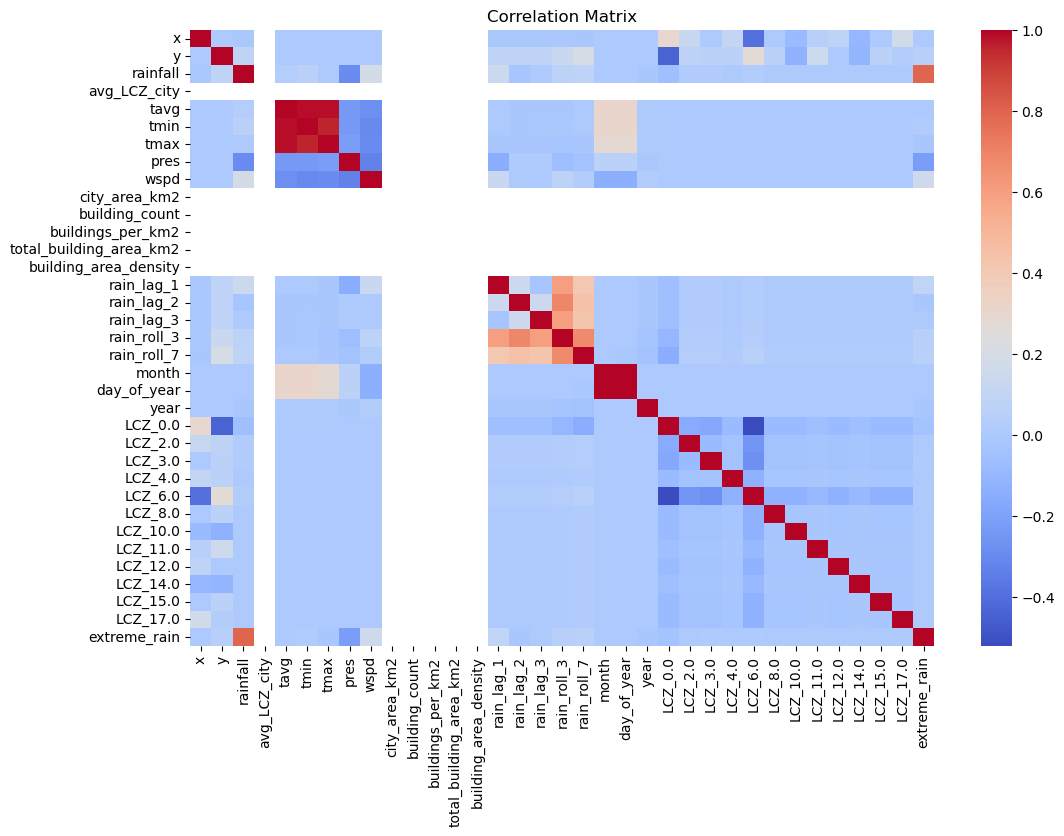


✅ FEATURE ENGINEERING COMPLETE (NO LEAKAGE, NO ERRORS)
Saved to: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_week7_ready.csv


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 0. Load dataset
# -----------------------------
df = pd.read_csv(r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_tif_Rlczbdw.csv").copy()

# -----------------------------
# 1. Date handling
# -----------------------------
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# -----------------------------
# 2. Spatial ID (grid definition)
# -----------------------------
df["grid_id"] = (
    df["x"].round(3).astype(str) + "_" + df["y"].round(3).astype(str)
)

# -----------------------------
# 3. Sort (VERY IMPORTANT for lags)
# -----------------------------
df = df.sort_values(["grid_id", "date"]).reset_index(drop=True)

# -----------------------------
# 4. LAG FEATURES (per grid)
# -----------------------------
df["rain_lag_1"] = df.groupby("grid_id")["rainfall"].shift(1)
df["rain_lag_2"] = df.groupby("grid_id")["rainfall"].shift(2)
df["rain_lag_3"] = df.groupby("grid_id")["rainfall"].shift(3)

# -----------------------------
# 5. ROLLING FEATURES (NO leakage)
# -----------------------------
df["rain_roll_3"] = (
    df.groupby("grid_id")["rainfall"]
    .shift(1)
    .rolling(3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df["rain_roll_7"] = (
    df.groupby("grid_id")["rainfall"]
    .shift(1)
    .rolling(7, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

# -----------------------------
# 6. TIME FEATURES
# -----------------------------
df["month"] = df["date"].dt.month
df["day_of_year"] = df["date"].dt.dayofyear
df["year"] = df["date"].dt.year

# -----------------------------
# 7. LCZ ENCODING
# -----------------------------
df["LCZ"] = df["LCZ"].astype("category")
df = pd.get_dummies(df, columns=["LCZ"], prefix="LCZ")

# -----------------------------
# 8. CREATE TARGET (THIS WAS YOUR MAIN ERROR)
# -----------------------------
# Extreme rain definition (you can adjust threshold later)
threshold = df["rainfall"].quantile(0.95)
df["extreme_rain"] = (df["rainfall"] > threshold).astype(int)

# -----------------------------
# 9. DROP ROWS WITH MISSING VALUES (from lag/rolling)
# -----------------------------
df = df.dropna().reset_index(drop=True)

# -----------------------------
# 10. FEATURES / LABELS
# -----------------------------
drop_cols = ["rainfall", "date", "grid_id", "extreme_rain"]

X = df.drop(columns=drop_cols)
y = df["extreme_rain"]

# -----------------------------
# 11. CORRELATION ANALYSIS
# -----------------------------
corr = df.corr(numeric_only=True)

print("\nTop correlations with extreme_rain:\n")
print(corr["extreme_rain"].sort_values(ascending=False))

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# -----------------------------
# 12. SAVE DATASET
# -----------------------------
output_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_week7_ready.csv"
df.to_csv(output_path, index=False)

print("\n✅ FEATURE ENGINEERING COMPLETE (NO LEAKAGE, NO ERRORS)")
print(f"Saved to: {output_path}")